# **Hybrid Retrieval on Unstructured Approach**

In [1]:
%pip install "unstructured[all-docs]"

Note: you may need to restart the kernel to use updated packages.


e:\The Leo Programmer\Internships\NRSC\Assignments\testing-models\.venv\Scripts\python.exe: No module named pip


In [2]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading Necessary Modules of Unstructured Library

from unstructured.chunking.title import chunk_by_title
from unstructured.partition.md import partition_md
from unstructured.partition.pdf import partition_pdf
from unstructured.staging.base import dict_to_elements

In [4]:
import unstructured.partition

help(unstructured.partition)

Help on package unstructured.partition in unstructured:

NAME
    unstructured.partition

PACKAGE CONTENTS
    api
    auto
    common (package)
    csv
    doc
    docx
    email
    epub
    html (package)
    image
    json
    md
    model_init
    msg
    ndjson
    odt
    org
    pdf
    pdf_image (package)
    ppt
    pptx
    rst
    rtf
    strategies
    text
    text_type
    tsv
    utils (package)
    xlsx
    xml

FILE
    e:\the leo programmer\internships\nrsc\assignments\testing-models\.venv\lib\site-packages\unstructured\partition\__init__.py




## **Data Ingestion Layer**

- Data ingestion layer is responsible for converting raw documents into structured, semantically meaningful, and traceable chunks that can be reliably used by retrieval and generation systems.

- Data ingestion includes document loading, parsing, cleaning, chunking, and metadata enrichment — and ends before embeddings are created.

In [5]:
# PDF Files Path

from pathlib import Path

pdf_dir = Path("../data/pdfs")
pdf_files = list(pdf_dir.glob("*.pdf"))
pdf_files

[WindowsPath('../data/pdfs/allafs.pdf'),
 WindowsPath('../data/pdfs/alldg.pdf'),
 WindowsPath('../data/pdfs/allrec.pdf'),
 WindowsPath('../data/pdfs/allsbe.pdf'),
 WindowsPath('../data/pdfs/bh1.pdf'),
 WindowsPath('../data/pdfs/budget_at_a_glance.pdf'),
 WindowsPath('../data/pdfs/Budget_Speech.pdf'),
 WindowsPath('../data/pdfs/Finance_Bill.pdf'),
 WindowsPath('../data/pdfs/frbm1.pdf'),
 WindowsPath('../data/pdfs/memo.pdf'),
 WindowsPath('../data/pdfs/OutcomeBudgetE2025_2026.pdf'),
 WindowsPath('../data/pdfs/Spotlight _ National Portal of India.pdf'),
 WindowsPath('../data/pdfs/vol1.pdf')]

In [46]:
# PDF Files Loading and Partitioning

from unstructured.partition.pdf import partition_pdf

all_elements = []

for pdf_path in pdf_files:
    elements = partition_pdf(
        filename=str(pdf_path),
        extract_images_in_pdf=False,
        #strategy = "hi_res",
        strategy = "fast",
        #hi_res_model_name="yolox",
        infer_table_structure=True,
        chunking_strategy="by_title",
        max_characters=3000,
        #new_after_n_chars=3800,
        combine_text_under_n_chars=200,
        #extract_image_block_output_dir=path,
    )

    # Attach source metadata manually (VERY IMPORTANT)
    for el in elements:
        el.metadata.source = pdf_path.name

    all_elements.extend(elements)

Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-strok

Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because No

In [7]:
for el in elements:
    el.metadata.source = pdf_path.name

all_elements.extend(elements)

In [8]:
all_elements

 ...]

In [47]:
# Create a dictionary to store counts of each type
category_counts = {}

for element in all_elements:
    category = str(type(element))
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# Unique_categories will have unique elements
unique_categories = set(category_counts.keys())
category_counts

{"<class 'unstructured.documents.elements.CompositeElement'>": 8139}

In [48]:
element_dict = [el.to_dict() for el in all_elements]

unique_types = set()

for item in element_dict:
    unique_types.add(item['type'])

print(unique_types)

{'CompositeElement'}


In [11]:
all_elements[0].to_dict()

{'type': 'CompositeElement',
 'element_id': '34a556e5fdda3f4c3493fa64de781cf2',
 'text': '£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA\n\nBÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026\n\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)',
 'metadata': {'file_directory': '..\\data\\pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 1,
  'orig_elements': 'eJzNlF1P2zAUhv+KlSuQcOQ4dj64K6xs1UZAELihqHLiE2otTarEbBS2/z47DWvIerMLJKTI8Xs+7GOfR757caCEFVR6oaRzjBzBBQliP8NESo5ZRnIcgyxwlnsSRA6U5OAcIWcFWkihhcl5cfK6bqSqhIa206XY1I96sQT1sNTGEjHqEpPU238qqZfGzGPemde1qrTNvLujjLv8CHk0dIP7I/RXc+4yq31ObMo/uos3BqfdtBpW9iSX6gnK67Wp2fltHIUqYSFVA7mum40NcN353B5hPl/LonX6mEqsoLuIshRF6xqX01Xe6sWqlqpQ0N0TJTTAxMNekHr+MYnNZ+PW4gEW1eMqg8ZEeXZjDU/2Dpz5IyHCt2Me70YBaiuQ/WVi6DnZiunQhj5f3E6vkvNpkqKLMzRLPs0mdmO9WXdlp0qX3YHHjSUEIkYijklAKWa5DzgOJMWFpB7kIDJW0HdsrMepS02jwr6xvWYscLnVjPm

In [12]:
all_elements[2].to_dict()

{'type': 'CompositeElement',
 'element_id': '92c238df00a6378a76335cca77373036',
 'text': 'Statement I - Consolidated Fund of India -\n\n®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ {ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ {ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ ÉÊ´É´É®hÉ I BÉE - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ {É®\n\nRevenue Account - Receipts Revenue Account - Disbursements Capital Account - Receipts Capital Account - Disbursements',
 'metadata': {'file_directory': '..\\data\\pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 1,
  'orig_elements': 'eJzNVVtvmzAU/isWzzWysTGhb1u3SdnT1HR9aarogA+NJQIomK5Ztv8+m9CFXLY9rJUqRY6/c75zT47vtgGWuMLKLowOLkmQSIwTIQRVKkuozFNJIeeCThCLSYxpwgCCCxKs0IIGC85mG+R1vdamAottj0vY1J1dLNE8LK2TTGQUMmc0yL8ZbZdOHKdxL25qU1lveXcnOPeiOGWhvL8ge5yGwmM5cZdz2POdIGg3rcWVr+SLecJy1kCOwU+nKEyJC23WmNt6vfGEMJzPfQnzeaOLNhg4FazQa6EsoWhDpwr6zFu7WNXaFAb7PkUsUpRxytUNF5csdR/Pa+ABF1W3ynDtWNwHtvjkexDMrOuP7zSZEkqu6qqtS+PioyafukqTuiDTShsg1Duym6ZP48bYs

In [ ]:
from unstructured.partition.pdf import partition_pdf

# Specify the path to your PDF file
filename = "../data/pdfs/allafs.pdf"

# Extract images, tables, and chunk text
pdf_elements = partition_pdf(
    filename=filename,
    extract_images_in_pdf=False,
    #strategy = "hi_res",
    strategy = "fast",
    hi_res_model_name="yolox",
    infer_table_structure=True,
    chunking_strategy="by_title",
    max_characters=3000,
    #new_after_n_chars=3800,
    combine_text_under_n_chars=200,
    #extract_image_block_output_dir=path,
)

pdf_elements[0].to_dict()

{'type': 'CompositeElement',
 'element_id': '34a556e5fdda3f4c3493fa64de781cf2',
 'text': '£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA\n\nBÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026\n\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)',
 'metadata': {'file_directory': '../data/pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 1,
  'orig_elements': 'eJzNlFtP2zAUx7+KlSeQSMjFzoW3wspWbQQEgReGqpP4mFpLkyoxWzu27z47DWvI+rIHJKTI8f9c7GOfn3z/bGGJS6zUXHLrhFg5uCKCGGwmEmbTMHdt4AnYlEUCch5j7vvWEbGWqICDAp3zbBV13XBZgcK20yVs6ic1X6B8XChtianvuDqpt/+QXC20mSWsM69qWSmTeX/vU+awI+L5kRM+HJG/mjGHGh0w16T8o7t4bbDaTatwaU5yJddY3qygQOu3dghZ4pzLBgtVNxsT4DjH5gTHKy5aq4+oYInGB2UJonW0y+rqbtV8WXMpJHa35Lt+aLue7YWZF5y4if5M3AoecV49LXNsdJRntlW4NjdgfX1yXQjMWCS7EVBuBTG/HIae062YDm3k4+Xd9Dq9mKYZuTwns/TDbGI2VptVV3YmVdkdd9zWKBaYMxHbtPC5TWMa2iCwsAVzuaAexThgb9hWj/mOr9sU9W3tNaWhw4ymNDBtH

In [ ]:
# Loading a Single File by PyPDFLoader to compare with Unstructured Library

from langchain_community.document_loaders import PyPDFLoader

file_path = "../data/pdfs/allafs.pdf"
loader = PyPDFLoader(file_path)

In [15]:
docs = loader.load()
docs[0]

Document(metadata={'producer': 'Microsoft Reporting Services PDF Rendering Extension 11.0.0.0', 'creator': 'Microsoft Reporting Services 11.0.0.0', 'creationdate': '2025-01-30T12:25:00+05:30', 'author': '', 'moddate': '2025-01-31T10:18:44+05:30', 'subject': '', 'title': 'AFS', 'source': '../data/pdfs/allafs.pdf', 'total_pages': 18, 'page': 0, 'page_label': '1'}, page_content='£ÉÉ®iÉ ºÉ®BÉEÉ®\nGOVERNMENT OF INDIA\nBÉäExpÉÒªÉ ºÉ®BÉEÉ®\nBÉEÉ\n2025-2026\nBÉEÉ\n´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ\nANNUAL FINANCIAL STATEMENT\nOF  THE\nCENTRAL GOVERNMENT\nFOR\n2025-2026\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ)\n(As laid before Parliament)\nÉÊ´ÉKÉªÉ ºÉÚSÉÉÒ\nCONTENTS\nÉÊ´É´É®hÉ I - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ - Statement I - Consolidated Fund of India -\n®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ Revenue Account - Receipts 1-3\n®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ Revenue Account - Disbursements 4-6\n{ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ Capital Account   - Receipts 7\n{ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ Capital Account 

*In both the cases, we can see the hindi text is coded in a different format.*

*"BÉäExpÉÒªÉ ºÉ®BÉEÉ®\nBÉEÉ\n2025-2026\nBÉEÉ\n´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ"*

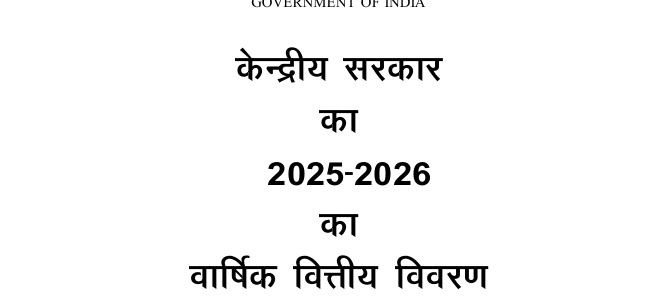

In [17]:
tables = [el for el in pdf_elements if el.category == "Table"]
tables

[]

In [18]:
pdf_elements[11].to_dict()

{'type': 'CompositeElement',
 'element_id': '6658ec68b9e0efc9f686e79ea2f51677',
 'text': 'Commodities and Services\n\n(ङ) िवधानमंडल रिहत संघ रा(cid:475) (cid:407)े(cid:361)ों के\n\n(e) Taxes of Union Territories\n\n3745.09\n\n4526.40\n\nकर सकल कर राज(cid:738) समेिकत िनिध म(cid:336) शािमल न िकये गए\n\nरा(cid:475)ों का भाग',
 'metadata': {'file_directory': '../data/pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 3,
  'orig_elements': 'eJzNVsmO2zgQ/RVBpxhoKtyXvs49CBDn1BMYXIrdBGzLkNWZ7gnm34ci5bHScZDJwYABg67HquKiVwsfvrWwhR3sx00K7X3TYo2p8Z4gZQxF3AqPnIoEcRG5MlRESaC9a9odjDbY0Wafb63v+yGkvR3hWPDWvvbP4+YJ0uPTmGc0J5022WtW/JXC+JTnhREdVTIrDn3aj5PzwwMxuMN3Dee8k1/umv+woBVTLTpyARf7PNEeX48j7KbLfEwvsP10sB7af7Iipi1sQhrAj/3wOhl03fvpEu8PIR7b2WJvdzDp7HZr47HLqrac/Dhudn1IMUH5UBRTiTBBRK4Ju8cm/ya7g32Ezf5552DIVmzadoSX6SO0f/S7aYExwbGx+9B8guFr8lA2Hl8PZdN1GrflsG950VhFA5YjB54jHiPLUjQoKgLEUmO89VfmRVcaRIcLLRVKNkNBOnUBF/NbZuXdn8/YELNqpn8WyyimkaoiQ5F1GYuMaZFJ0dLqhhfOpqh5VeizB

Our PDF visually has a table with:

Hindi + English headers

Numeric columns aligned properly

But internally, the PDF is stored as:

Absolutely positioned text blocks

No real “table structure”

So Unstructured is extracting text, not a table, and it ends up as:

```
Commodities and Services
(e) Taxes of Union Territories
3745.09
4526.40
कर सकल कर राज...
-> Row/column relationships are lost
```

Government and budget PDFs often lack true table structure; Unstructured extracts them as text, so numeric tables should be handled with a dedicated table extraction pipeline when accuracy matters.

In [49]:
# Extract images, tables, and chunk text

for element in all_elements:
    category = str(type(element))
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# Unique_categories will have unique elements
unique_categories = set(category_counts.keys())
print(category_counts)

element_dict = [el.to_dict() for el in all_elements]

unique_types = set()

for item in element_dict:
    unique_types.add(item['type'])

print(unique_types)

{"<class 'unstructured.documents.elements.CompositeElement'>": 16278}
{'CompositeElement'}


In [50]:
# Better approach - ALL elements for hybrid retrieval

for el in all_elements:
    print(f"{el.category:15} | Page {el.metadata.page_number} | {el.text[:80]}...")

CompositeElement | Page 1 | £ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA

BÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉ...
CompositeElement | Page 1 | xÉ<Ç ÉÊnããÉÉÒ, 1 {ÉE®´É®ÉÒ, 2025 New Delhi, February 1, 2025

ÉÊxÉàÉÇãÉÉ ºÉÉÒiÉÉ...
CompositeElement | Page 1 | Statement I - Consolidated Fund of India -

®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´...
CompositeElement | Page 1 | Statement I A - Disbursements ‘Charged’

1-3 4-6 7 8-10

‘£ÉÉÉÊ®iÉ’ ºÉÆÉÊ´ÉiÉ®hÉ...
CompositeElement | Page 1 | |ÉÉÉÎ{iÉªÉÉÆ ºÉÆÉÊ´ÉiÉ®hÉ

Receipts Disbursements

14 15

ÉÊ´ÉvÉÉxÉàÉÆbãÉ ®ÉÊciÉ...
CompositeElement | Page 3 | मु(cid:421) शीष(cid:330) Major Head

वा(cid:721)िवक Actuals 2023-2024

बजट अनुमा...
CompositeElement | Page 3 | A. TAX REVENUE (a) Goods and Services Tax

Central Goods and Services Tax

0005
...
CompositeElement | Page 3 | Union Territory Goods and Services Tax (UTGST)

0007

5497.16

4900.00

एकीकृत व...
CompositeElement | Page 3 | Corporation Tax

होटल (cid:366)ा(cid:304)(cid:593)यों पर कर (cid:623)ाज कर अ

### **Chunking**

In [51]:
# Create proper chunks with metadata
chunks = []

for el in all_elements:
    chunk = {
        "content": el.text,
        "category": el.category,  # Title, Table, Text, etc.
        "page": el.metadata.page_number,
        "source": el.metadata.filename,
        "is_table": el.category == "Table",
        "table_html": el.metadata.text_as_html if el.category == "Table" else None
    }
    chunks.append(chunk)

print(f"---> {len(chunks)} chunks ready for BM25 + Semantic indexing")

---> 8139 chunks ready for BM25 + Semantic indexing


In [52]:
# IGNORE = {"Header", "Footer", "UncategorizedText"}

IGNORE = {"Footer", "UncategorizedText"}

elements = [
    el for el in all_elements
    if el.category not in IGNORE and el.text.strip()
]

In [53]:
# Group elements by section title to improve chunking and retrieval

from collections import defaultdict

sections = []
current_section = {
    "title": None,
    "elements": [],
    "page_start": None
}

for el in elements:
    if el.category == "Title":
        if current_section["elements"]:
            sections.append(current_section)

        current_section = {
            "title": el.text,
            "elements": [],
            "page_start": el.metadata.page_number
        }
    else:
        current_section["elements"].append(el)

# flush
if current_section["elements"]:
    sections.append(current_section)

In [54]:
current_section

{'title': None,
 'elements': [<unstructured.documents.elements.CompositeElement at 0x24811a68380>,
  ...],
 'page_start': None}

In [82]:
# Section wise chunking: grouping by titles and splitting large sections

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,       # or 500-700 tokens
    chunk_overlap=200,     # optional
    separators=["\n\n", "\n", ". ", " "]

)

chunks = []

for sec in sections:
    # merge section text
    section_text = "\n\n".join(el.text for el in sec["elements"])

    # split section into chunks
    sub_chunks = splitter.split_text(section_text)

    # prepend title to each sub-chunk
    for sub in sub_chunks:
        cleaned = sub.lstrip(" .\n")
        chunks.append({
            "content": f"{sec['title']}\n\n{cleaned}",
            "title": sec['title'],                    # section title
            "page_start": sec['page_start'],          # first page of section
            "page_end": sec['elements'][-1].metadata.page_number,  # last page of section
            "source": sec['elements'][0].metadata.filename,        # file name
            "category": [el.category for el in sec["elements"]]   # list of element types
        })

In [56]:
for i, ch in enumerate(chunks[:4]):
    print(f"\n--- Chunk {i} ---")
    print(ch["content"])


--- Chunk 0 ---
None

£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA

BÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026

(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)

xÉ<Ç ÉÊnããÉÉÒ, 1 {ÉE®´É®ÉÒ, 2025 New Delhi, February 1, 2025

ÉÊxÉàÉÇãÉÉ ºÉÉÒiÉÉ®ÉàÉxÉ ÉÊ´ÉkÉ àÉÆjÉÉÒ Nirmala Sitharaman Minister of Finance

ÉÊ´ÉKÉªÉ ºÉÚSÉÉÒ CONTENTS

ÉÊ´É´É®hÉ I - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ -

Statement I - Consolidated Fund of India -

®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ {ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ {ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ ÉÊ´É´É®hÉ I BÉE - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ {É®

Revenue Account - Receipts Revenue Account - Disbursements Capital Account - Receipts Capital Account - Disbursements

Statement I A - Disbursements ‘Charged’

1-3 4-6 7 8-10

‘£ÉÉÉÊ®iÉ’ ºÉÆÉÊ´ÉiÉ®hÉ

on the Consolidated Fund of India

11-12

ÉÊ´É´É®hÉ II - £ÉÉ®iÉ BÉEÉÒ +ÉÉBÉEÉÎºàÉBÉEiÉÉ

# Interpretation: PDF Ingestion Challenges in Multilingual Government Documents

## Overview

During document ingestion, certain PDF files—particularly Indian government and budget documents—exhibit inconsistent text extraction quality. This behavior is not caused by chunking strategies, prompt design, or retrieval logic, but by underlying issues related to **PDF encoding and font usage**.

These PDFs often contain a mixture of English and Hindi text, along with structured tables and numerical data. While numerical values are generally extracted correctly, textual content—especially Hindi—may appear garbled or unreadable.

---

## Root Cause Analysis

### Legacy Non-Unicode Fonts

Many government PDFs use **legacy, non-Unicode fonts** (such as Kruti Dev or custom CID-based fonts). In these cases:

* Text is stored as font glyph positions rather than Unicode characters.
* Extracted output may appear as corrupted Latin characters (e.g., `£ÉÉ®iÉ ºÉ®BÉEÉ®`) instead of readable Hindi text.
* This is a **font-encoding issue**, not an OCR or parsing error.

### Mixed Encoding Within a Single Document

It is common for a single PDF to contain:

* Sections using legacy font encodings
* Sections using proper Unicode text

As a result:

* Some Hindi text extracts correctly
* Other Hindi text becomes unreadable
* English text and numbers usually remain intact

---

## Why Standard Extraction Fails

Libraries such as **Unstructured** extract text objects as they exist in the PDF. They do not:

* Remap legacy font encodings
* Transliterate glyph-based text
* Repair corrupted character mappings

Therefore, extraction faithfully reproduces the underlying encoding—even if it is unreadable.

---

## PDF Complexity Classification

These documents fall under a higher difficulty category for ingestion:

| Tier       | Description                      |
| ---------- | -------------------------------- |
| Tier 1     | Born-digital, clean Unicode PDFs |
| Tier 2     | Unicode multilingual PDFs        |
| **Tier 3** | Legacy-font government PDFs      |
| Tier 4     | Fully scanned image PDFs         |

Tier-3 PDFs can be more problematic than scanned documents because text appears present but is semantically corrupted.

---

## Impact on Tables and Numerical Data

* Numeric values extract correctly because they use standard ASCII characters.
* Table headers and labels may be corrupted if they rely on legacy fonts.
* This causes partial loss of semantic meaning even when row values are intact.

As a result, tables may appear structurally correct but lack reliable context.

---

## Recommended Ingestion Strategy

### Force OCR for Legacy PDFs (Preferred)

To reliably extract multilingual text, ingestion should **force OCR even when text exists** in the PDF:

* OCR captures visual text instead of embedded glyphs
* Produces proper Unicode output for Hindi and English
* Improves chunk quality, retrieval accuracy, and RAG stability

This approach is slower but significantly more accurate.

---

### Conditional OCR (Production-Grade Approach)

A robust ingestion pipeline may:

1. Attempt standard extraction
2. Detect garbled text patterns (non-ASCII-heavy output)
3. Re-run OCR selectively for affected pages

This balances performance and correctness.

---

## Approaches Not Recommended

* Manual font-to-Unicode post-processing
* Custom glyph remapping logic

These solutions are font-specific, brittle, and difficult to maintain.

---

## Implications for RAG Systems

Without OCR:

* Retrieved chunks may be inconsistent
* Answers may vary across generations
* Rerankers may select semantically incorrect text

With OCR:

* Chunks are linguistically stable
* Multilingual retrieval improves
* Factual consistency increases
* Hallucinations decrease

---

## Key Takeaway

> Indian government PDFs frequently use legacy non-Unicode fonts, resulting in corrupted text extraction. Reliable ingestion requires forcing OCR even when textual content appears to be present.

---

## Final Recommendation

For document ingestion pipelines:

| Document Type         | Strategy                                |
| --------------------- | --------------------------------------- |
| Budget / Finance PDFs | Hi-res OCR ingestion                    |
| Research / Reports    | Fast text extraction                    |
| Mixed collections     | Encoding detection with conditional OCR |

This approach ensures reliable downstream retrieval, question answering, and analytics.

In [57]:
chunks[0]['content']

'None\n\n£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA\n\nBÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026\n\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)\n\nxÉ<Ç ÉÊnããÉÉÒ, 1 {ÉE®´É®ÉÒ, 2025 New Delhi, February 1, 2025\n\nÉÊxÉàÉÇãÉÉ ºÉÉÒiÉÉ®ÉàÉxÉ ÉÊ´ÉkÉ àÉÆjÉÉÒ Nirmala Sitharaman Minister of Finance\n\nÉÊ´ÉKÉªÉ ºÉÚSÉÉÒ CONTENTS\n\nÉÊ´É´É®hÉ I - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ -\n\nStatement I - Consolidated Fund of India -\n\n®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ {ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ {ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ ÉÊ´É´É®hÉ I BÉE - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ {É®\n\nRevenue Account - Receipts Revenue Account - Disbursements Capital Account - Receipts Capital Account - Disbursements\n\nStatement I A - Disbursements ‘Charged’\n\n1-3 4-6 7 8-10\n\n‘£ÉÉÉÊ®iÉ’ ºÉÆÉÊ´ÉiÉ®hÉ\n\non the Consolidated Fund of India\n\n11-12\n\nÉÊ´É´É®hÉ II - £ÉÉ®iÉ BÉEÉÒ +

In [58]:
chunks[4]

{'content': "None\n\nServices other than Goods and Services Tax\n\n0030 0031 0032 0034\n\n0.31 1.31 6.12 33777.78 543249.51\n\n... ... ... 37000.00 561845.00\n\nBanking Cash Transaction Tax Customs Union Excise Duties Sales Tax Service Tax\n\nब(cid:339)िकंग नकद सं(cid:681)वहार कर सीमा शु(cid:651) क(cid:336)(cid:363)ीय उ(cid:523)ाद शु(cid:651) िब(cid:354)ी कर सेवा कर व(cid:721)ु और सेवाओं पर अ(cid:586) कर और शु(cid:651) Other Taxes and Duties on\n\n0036 0037 0038 0040 0044 0045\n\n414.32 233118.97 305362.18 ... 424.96 3929.08\n\n... 237745.00 319000.00 ... 100.00 5000.00\n\nCommodities and Services\n\n(ङ) िवधानमंडल रिहत संघ रा(cid:475) (cid:407)े(cid:361)ों के\n\n(e) Taxes of Union Territories\n\n3745.09\n\n4526.40\n\nकर सकल कर राज(cid:738) समेिकत िनिध म(cid:336) शािमल न िकये गए\n\nरा(cid:475)ों का भाग\n\nwithout Legislature\n\nGROSS TAX REVENUE State's share excluded from the Consolidated Fund\n\n3465518.58 1129493.71\n\n3840170.40 1247211.28\n\nक(cid:336)(cid:363) सरकार का कर राज(cid:

In [60]:
len(chunks)

5596

In [71]:
# Find the element with text "References" and category "Title"
title = [
    el for el in all_elements
    if el.category == "Title"
]

In [72]:
title

[]

In [73]:
sections[0]
section_text = "\n\n".join(el.text for el in sec["elements"])

In [78]:
section_text

'£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA\n\nBÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026\n\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)\n\nxÉ<Ç ÉÊnããÉÉÒ, 1 {ÉE®´É®ÉÒ, 2025 New Delhi, February 1, 2025\n\nÉÊxÉàÉÇãÉÉ ºÉÉÒiÉÉ®ÉàÉxÉ ÉÊ´ÉkÉ àÉÆjÉÉÒ Nirmala Sitharaman Minister of Finance\n\nÉÊ´ÉKÉªÉ ºÉÚSÉÉÒ CONTENTS\n\nÉÊ´É´É®hÉ I - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ -\n\nStatement I - Consolidated Fund of India -\n\n®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ {ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ {ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ ÉÊ´É´É®hÉ I BÉE - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ {É®\n\nRevenue Account - Receipts Revenue Account - Disbursements Capital Account - Receipts Capital Account - Disbursements\n\nStatement I A - Disbursements ‘Charged’\n\n1-3 4-6 7 8-10\n\n‘£ÉÉÉÊ®iÉ’ ºÉÆÉÊ´ÉiÉ®hÉ\n\non the Consolidated Fund of India\n\n11-12\n\nÉÊ´É´É®hÉ II - £ÉÉ®iÉ BÉEÉÒ +ÉÉBÉEÉÎº

In [79]:
sections

[{'title': None,
  'elements': [<unstructured.documents.elements.CompositeElement at 0x24811a68380>,
   ...],
  'page_start': None}]

In [80]:
# Generate embeddings and index with Chroma

from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma

chunk_docs = [
    Document(
        page_content=chunk["content"],
        metadata={
            "title": chunk["title"],
            "page_start": chunk["page_start"],
            "page_end": chunk["page_end"],
            "source": chunk["source"],
            "category": ", ".join(chunk["category"])  # convert list to string
        }
    )
    for chunk in chunks
]

print("Generating embeddings and indexing...")
embeddings = OllamaEmbeddings(model="nomic-embed-text")

vectorstore = Chroma.from_documents(
    documents=chunk_docs,
    embedding=embeddings,
    persist_directory="./chroma_db",
    collection_name="unstructured_test"
)

Generating embeddings and indexing...


In [ ]:
# Test retrieval
vectorstore_retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

# Test query
query = "Graduation rates of Students with disabilities in higher education institutions"
relevant_docs = vectorstore_retriever.invoke(query)

print(f"Found {len(relevant_docs)} relevant chunks:")
for doc in relevant_docs:
    print("\n---")
    print(f"Source: {doc.metadata['source']}")
    print(f"Pages: {doc.metadata['page_start']} - {doc.metadata['page_end']}")
    print(f"Title: {doc.metadata['title']}")
    print(f"Content: {doc.page_content[:500]}...")

Found 5 relevant chunks:

---
Source: allafs.pdf
Content: None

Scholarship for Students with Disabilidties:..The main objective of the umbrella scholarship Scheme is to empower students with disabilities to study further in order to earn their livelihood and to find a dignified place in the society, as they face several barriers-physical, financial, and psychological in pursuing studies and living with dignity,

6.

7.

National University of Rehabilitation Science and Disabiltiy Studies:..This provision is

made for setting up a National University o...

---
Source: allafs.pdf
Content: None

8.

9.

Centre for Disability Sports:..The Centre encourages Persons with disabilities to pursue

sports.

Support to National Institutes:..Provide professional training courses with a view to develop trained manpower in the disability sector and provide various other rehabilitation services. These institutes are registered societies and are fully financed by the Central Government.

10.

Budgeta

In [ ]:
similar_docs = vectorstore.similarity_search("Graduation rates of Students with disabilities in higher education institutions")

for doc in similar_docs:
    print("\n---")
    print(f"Source: {doc.metadata['source']}")
    print(f"Pages: {doc.metadata['page_start']} - {doc.metadata['page_end']}")
    print(f"Title: {doc.metadata['title']}")
    print(f"Content: {doc.page_content[:500]}...")